# Prediction Insight Engine #

*Import Libraries*


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
import time

*Load Dataset*

In [3]:
df = pd.read_csv("RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")
print(df.head())


   house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
0    100001       1973         5          4             7.6         23   
1    100002       1560         3          3             6.3         13   
2    100003       2071         4          3             5.8          9   
3    100004       2640         5          3             7.7         12   
4    100005       1498         3          3             3.8         15   

   distance_city_km  lot_size_sqft  has_garage  has_pool  \
0              11.9           5220           1         0   
1              15.8           3882           1         0   
2              21.1           4488           0         0   
3               7.9           3614           1         1   
4              24.0           2663           0         0   

   renovation_years_ago  house_price_inr  
0                     0         40275084  
1                    13         26812029  
2                     9         29315677  
3                     

## Part B: Dataset Understanding & Preparation ##

$ Q.7   Identify Independent and Dependent Variables $

* Independent Variables

In [4]:
x = df[ 
    [
    "house_id",
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "age_years",
    "distance_city_km",
    "lot_size_sqft",
    "has_garage",
    "has_pool",
    "renovation_years_ago"
] 
    ]

* Dependent variables

In [5]:
y = df["house_price_inr"]

* Display

In [6]:
print("Independent Variables:")
print(x.columns.tolist())

print("\nDependent Variable:")
print("HousePrice")

Independent Variables:
['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago']

Dependent Variable:
HousePrice


$ 8. Visualize Relationships Between Features and Target
 $

 * House Area vs House Price

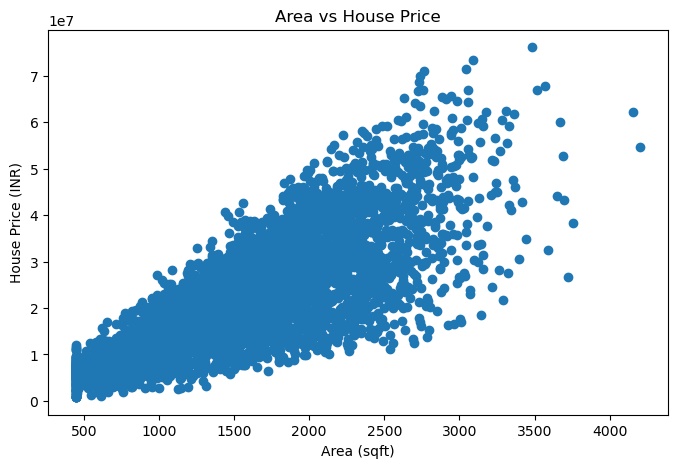

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["area_sqft"],
    df["house_price_inr"]
)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price (INR)")
plt.title("Area vs House Price")

plt.show()


$ Bedrooms vs House Price$

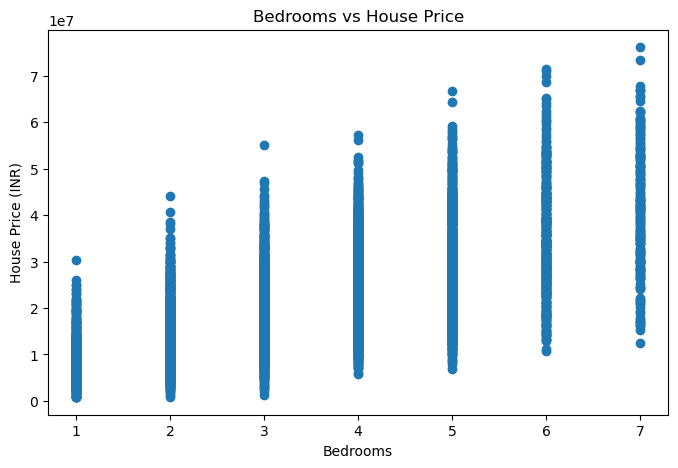

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["bedrooms"],
    df["house_price_inr"]
)

plt.xlabel("Bedrooms")
plt.ylabel("House Price (INR)")
plt.title("Bedrooms vs House Price")

plt.show()

$ Bathrooms vs House Price$

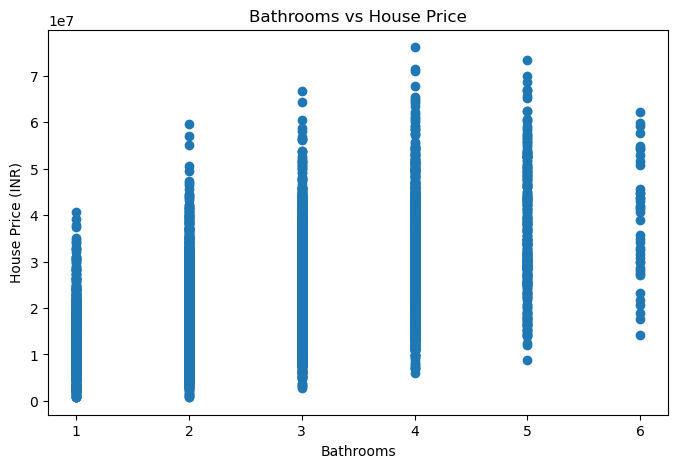

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["bathrooms"],
    df["house_price_inr"]
)

plt.xlabel("Bathrooms")
plt.ylabel("House Price (INR)")
plt.title("Bathrooms vs House Price")

plt.show()

$ Location Score vs House Price$

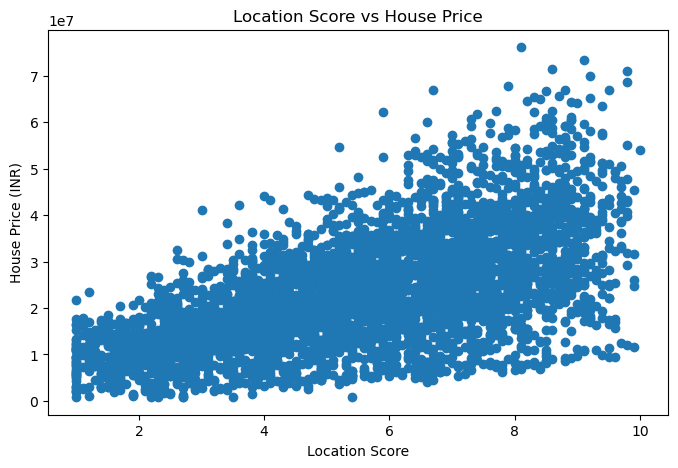

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["location_score"],
    df["house_price_inr"]
)

plt.xlabel("Location Score")
plt.ylabel("House Price (INR)")
plt.title("Location Score vs House Price")

plt.show()

$ Correlation$

In [11]:
df.corr(numeric_only=True)

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
house_id,1.000000,-0.021909,-0.004517,-0.004604,-0.004775,-0.021212,0.001294,-0.029708,0.025713,0.023900,-0.025655,-0.015115
area_sqft,-0.021909,1.000000,0.849167,0.671420,0.002268,-0.026760,-0.005440,0.753398,0.223386,-0.020960,-0.002509,0.755434
bedrooms,-0.004517,0.849167,1.000000,0.784770,-0.009210,-0.010470,0.004046,0.638159,0.260494,-0.014597,-0.001663,0.644772
bathrooms,-0.004604,0.671420,0.784770,1.000000,0.010847,-0.010608,-0.013661,0.502891,0.191962,-0.015585,-0.000708,0.527044
location_score,-0.004775,0.002268,-0.009210,0.010847,1.000000,0.008589,-0.744107,-0.011554,0.003171,0.183403,-0.006995,0.588531
age_years,-0.021212,-0.026760,-0.010470,-0.010608,0.008589,1.000000,-0.016373,-0.023948,0.015067,-0.005914,0.239137,-0.089454
distance_city_km,0.001294,-0.005440,0.004046,-0.013661,-0.744107,-0.016373,1.000000,0.007581,-0.005491,-0.136011,0.007241,-0.469431
lot_size_sqft,-0.029708,0.753398,0.638159,0.502891,-0.011554,-0.023948,0.007581,1.000000,0.177372,-0.016957,-0.002511,0.567751
has_garage,0.025713,0.223386,0.260494,0.191962,0.003171,0.015067,-0.005491,0.177372,1.000000,0.010914,0.020607,0.176934
has_pool,0.023900,-0.020960,-0.014597,-0.015585,0.183403,-0.005914,-0.136011,-0.016957,0.010914,1.000000,-0.012153,0.102015


$ Simple heatmap: $

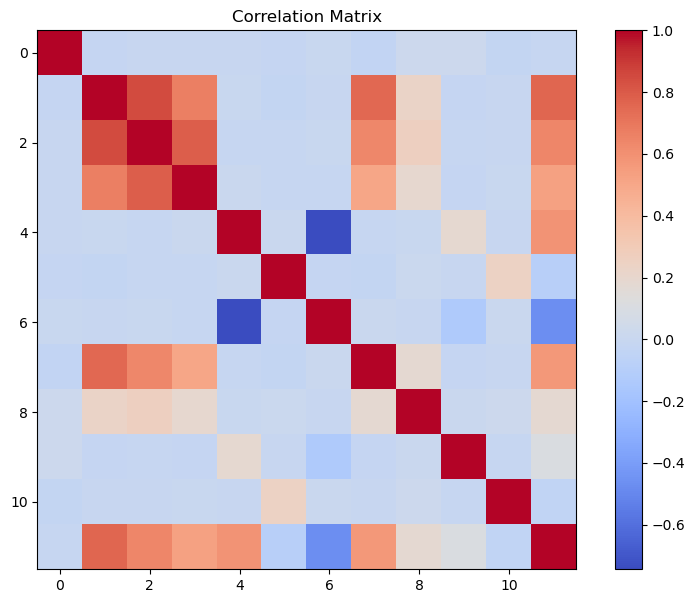

In [15]:
plt.figure(figsize=(10,7))

plt.imshow(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

$ Q9 Train Test Split$

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training data",x_train.shape)
print("Testing data", x_test.shape)


Training data (3360, 11)
Testing data (840, 11)


# Part C — Simple Linear Regression #

$ Q 10 Simple Linear Regression $

In [22]:

x = df[["area_sqft"]]
y = df["house_price_inr"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(y_pred)

[34402357.02127601 27333546.70007102 26771591.06784133 21802720.214442
 31045411.53400921 24287155.64114166 18608446.09439957 37419171.46798275
 27244816.86340317 28043385.39341378 13402962.34321932 12663547.03765394
 27274393.47562579 15931762.68825291 17765512.64605504 24050542.74336074
 35851611.02018416 21403435.9494367  33529846.96070888 33130562.69570357
 29374332.94343146  8079172.14314861 27067357.19006748 33145351.00181488
 23961812.9066929  28841953.92342439 36428354.95852515 20752750.48053917
 26860320.90450918 25144877.3955975  31888344.98235374 18845058.99218049
 20767538.78665047 35792457.79573892 32701701.81847565 22246369.39778123
 12841006.71098964 20161218.23608686 29921500.26954984 10238264.83539951
 22630865.35667522 16419776.78992606 19007730.35940488 26076540.68060988
 39593052.46634497 31193294.59512228 16893002.5854879  27777195.88341024
 44887266.05419306 24405462.09003213 30542609.12622475 32820008.26736612
 18830270.68606919 23030149.62168052 21817508.5205533

$ Q11. Regression Line $

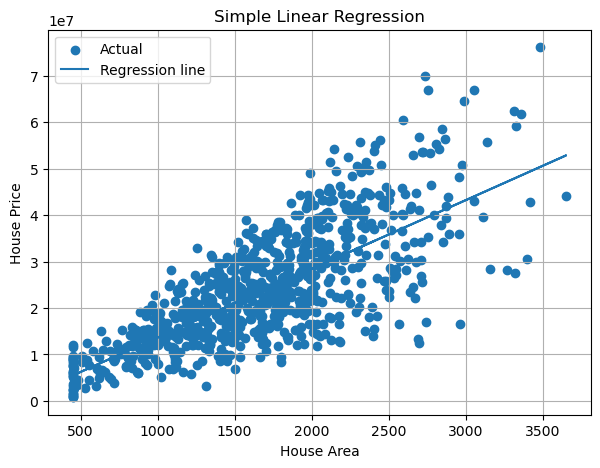

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(x_test, y_test,label="Actual")
plt.plot(x_test, y_pred, label="Regression line")

plt.xlabel("House Area")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

$ Q12 .Check assumptions $

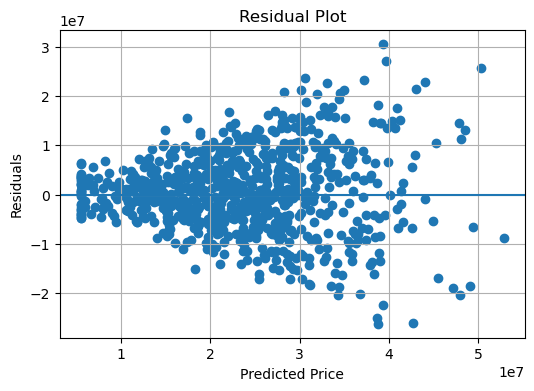

In [24]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

# Part D — Model Evaluation #

$ Q13 — MSE, MAE, RMSE, R², Adjusted R² $


In [25]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mse)

n = len(y_test)
p = x_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)
print("RMSE:", rmse)
print("Adjusted R2:", adjusted_r2) 

MSE: 66989260021849.47
MAE: 6294593.696131912
R2: 0.5625199587991578
RMSE: 8184696.696997969
Adjusted R2: 0.5619979062440257


In [26]:
print("""
MSE:
Lower MSE means better model performance.

MAE:
It shows the average prediction error.
Lower MAE is better.

RMSE:
It shows the average prediction error in the
same unit as house price.
Lower RMSE is better.

R2 Score:
It shows how much variation in house price
is explained by the model.
Higher R2 is better.

Adjusted R2:
It is useful when comparing models with
different numbers of features.
Higher value is better.
""")


MSE:
Lower MSE means better model performance.

MAE:
It shows the average prediction error.
Lower MAE is better.

RMSE:
It shows the average prediction error in the
same unit as house price.
Lower RMSE is better.

R2 Score:
It shows how much variation in house price
is explained by the model.
Higher R2 is better.

Adjusted R2:
It is useful when comparing models with
different numbers of features.
Higher value is better.



# Part E — Multiple Linear Regression #

In [29]:
x = df[ [
    "house_id",
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "age_years",
    "distance_city_km",
    "lot_size_sqft",
    "has_garage",
    "has_pool",
    "renovation_years_ago"
] ]

y = df["house_price_inr"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(x_train, y_train)

y_pred_multi = model_multi.predict(x_test)
print(y_pred_multi)

[39047318.73935103 31354554.26440009 16530039.70939722 31612138.45466145
 21141040.04304752 29027634.71059287  8348107.3975808  41456782.23540311
 20117283.29949803 41803941.58151557 26318626.18617693 14423121.68652298
 21703986.62859431 17337502.60955608 16096232.71111847 32796477.8953924
 26718391.66394686 11001876.58981331 34429993.6146265  47676486.30005874
 24956745.84688472  2296706.15786694 29289473.68146789 44360169.44222064
 26992742.02426369 20318939.078421   31652274.88241749 13278020.95774944
 37086614.80044854 17672112.78022146 44404881.4225378  30754786.21309591
 26146309.77470956 26085147.22420275 23912809.69523249 20820058.17566041
 21626550.9744688  16405637.82729122 37959264.31030118 16847605.12370332
 19151031.76177598 19487452.68575669 25124697.38090821 24569667.00544452
 39687803.46775001 28065224.68112808 21605164.68596668 36640244.36169606
 43034475.94773653 15610969.94271776 40453279.26119798 31317237.60969056
 24808155.09454316 24236645.59466715 28587504.322528

$ Q16 Compare with Simple Linear Regression $ 

In [30]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
mae_multi = mean_absolute_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)

print("Multiple Linear Regression Metrics:")
print("MSE:", mse_multi)
print("MAE:", mae_multi)
print("R2:", r2_multi)
print("RMSE:", rmse_multi)

Multiple Linear Regression Metrics:
MSE: 12597222158307.709
MAE: 2605648.611505146
R2: 0.9177325847899332
RMSE: 3549256.564170546


In [31]:
print("""
Simple Linear Regression uses only area_sqft
to predict house price.

Multiple Linear Regression uses many features such as:

- Area
- Bedrooms
- Bathrooms
- Location Score
- Property Age
- Distance from City
- Lot Size
- Garage
- Pool
- Renovation Age

Therefore, Multiple Linear Regression can use
more information and may give better predictions.
""")


Simple Linear Regression uses only area_sqft
to predict house price.

Multiple Linear Regression uses many features such as:

- Area
- Bedrooms
- Bathrooms
- Location Score
- Property Age
- Distance from City
- Lot Size
- Garage
- Pool
- Renovation Age

Therefore, Multiple Linear Regression can use
more information and may give better predictions.



## Part F — Polynomial Regression

$ Q18 Polynomial Regression Degree 2  $

In [50]:
x = df[["area_sqft"]]
y = df["house_price_inr"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)
y_train_poly = poly.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

y_pred_poly = poly_model.predict(y_train_poly)

## Visual comparison

$ Linear$

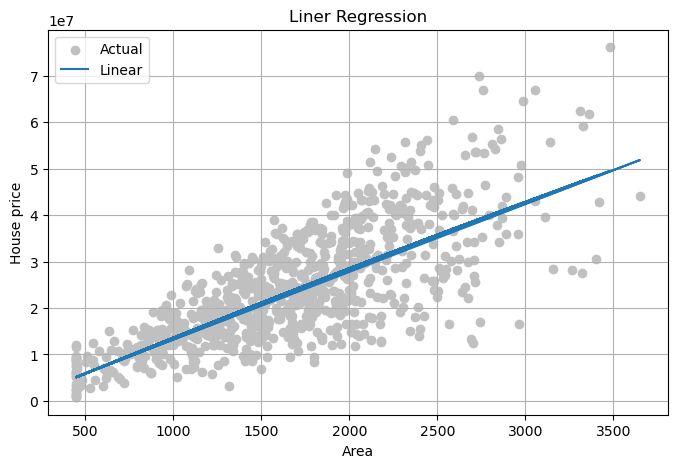

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(x_test, y_test, label = "Actual", color ="Silver")
plt.plot(x_test, y_pred_poly, label = "Linear")

plt.xlabel("Area")
plt.ylabel("House price")
plt.title("Liner Regression")
plt.grid(True)
plt.legend()
plt.show()

$ Polynomial$

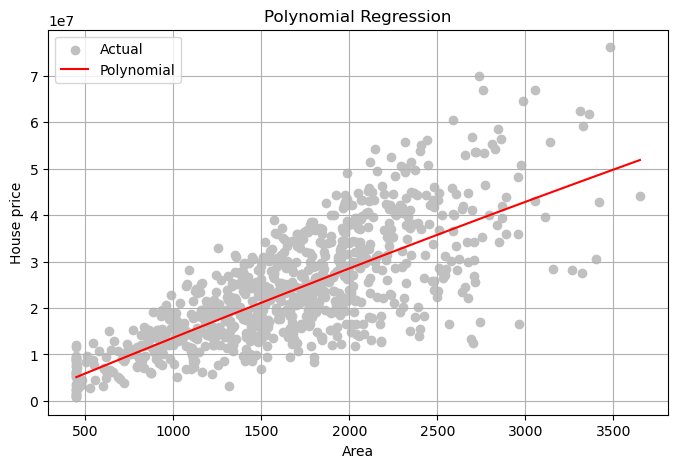

In [46]:
plot_data = x_test.copy()

plot_data["prediction"] = y_pred_poly

plot_data = plot_data.sort_values("area_sqft")

plt.figure(figsize=(8,5))
plt.scatter(x_test, y_test, label = "Actual", color ="Silver")
plt.plot(plot_data["area_sqft"],plot_data['prediction'],label ="Polynomial",color = "red")
plt.xlabel("Area")
plt.ylabel("House price")
plt.title("Polynomial Regression")
plt.grid(True)
plt.legend()
plt.show()

$ Q20 Identify signs of overfitting or underfitting $

In [51]:
train_poly = poly_model.predict(
    x_train_poly
)

train_r2_poly = r2_score(
    y_train,
    train_poly
)

test_r2_poly = r2_score(
    y_test,
    y_pred_poly
)

print("Training R2:", train_r2_poly)

print("Testing R2:", test_r2_poly)

Training R2: 0.5724674245504779
Testing R2: 0.5626917978136464


In [56]:
print("""
If Training R2 and Testing R2 are both low:
Underfitting.

If Training R2 and Testing R2 are good and close:
Good Fit.

If Training R2 is very high but Testing R2 is
much lower:
Overfitting.
""")


If Training R2 and Testing R2 are both low:
Underfitting.

If Training R2 and Testing R2 are good and close:
Good Fit.

If Training R2 is very high but Testing R2 is
much lower:
Overfitting.



# Part G — Gradient Descent


 Gradient Descent ek optimization algorithm hai jo model ke parameters ko gradually update karta hai taaki error/cost minimum ho.

Start with random/initial values
          ↓

Make prediction

          ↓

Calculate error

          ↓

Calculate gradient


          ↓

Update parameters

          ↓

Repeat

          ↓

Minimum error

Easy example

Agar model ka error bahut high hai, Gradient Descent parameters ko thoda-thoda change karta hai aur error kam karta hai. #

$ Q22. Implement Batch Gradient Descent from Scratch$

Beta 0: 1.1139026209353441e-16
Beta 1: 0.7554338331792643


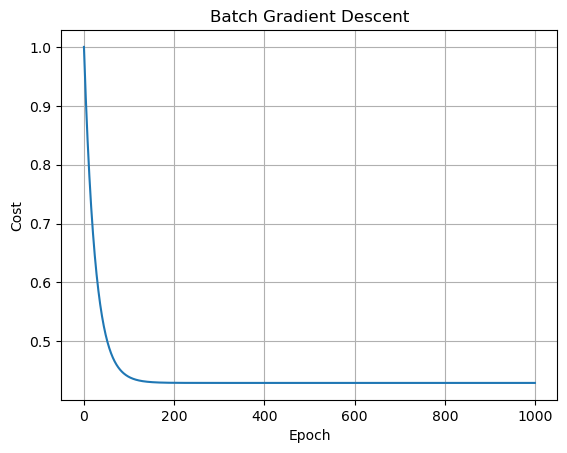

In [57]:
x = df["area_sqft"].values
y = df["house_price_inr"].values

x_mean = np.mean(x)
x_std = np.std(x)

y_mean = np.mean(y)
y_std = np.std(y)

x = (x - x_mean) / x_std
y = (y - y_mean) / y_std

beta0 = 0
beta1 = 0

learning_rate = 0.01
epochs = 1000

costs = []

n = len(x)

for epoch in range(epochs):
        y_pred = beta0 + beta1 * x
        error = y_pred - y

        cost = np.mean(error**2)
        costs.append(cost)

        grandient_b0 = (2/n) * np.sum(error)
        grandient_b1 = (2/n) * np.sum(error * x)

        beta0 = beta0 - learning_rate * grandient_b0
        beta1 = beta1 - learning_rate * grandient_b1

print("Beta 0:", beta0)
print("Beta 1:", beta1)

plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Batch Gradient Descent")
plt.grid(True)
plt.show()


$ Q23. Stochastic Gradient Descent (SGD)$

Beta 0: 0.11111375023348187
Beta 1: 0.9185440730973732


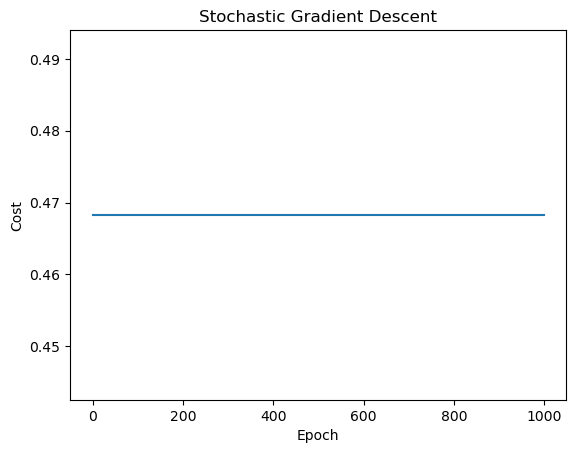

In [61]:

x = df["area_sqft"].values
y = df["house_price_inr"].values

x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

beta0 = 0
beta1 = 0

learning_rate = 0.01
epoch = 100

costs = []

n = len(x)

for epoch in range(epochs):
    for i in range(n):
        y_pred = beta0 + beta1 * x[i]
        error = y_pred - y[i]
        gradient_b0 = 2 * error
        gradient_b1 = 2 * error * x[i]

        beta0 = beta0 - learning_rate * gradient_b0
        beta1 = beta1 - learning_rate * gradient_b1

    y_pred_all = beta0 + beta1 * x
    cost = np.mean((y_pred_all - y) ** 2)

    costs.append(cost)

print("Beta 0:", beta0)
print("Beta 1:", beta1)

plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Stochastic Gradient Descent")
plt.show()


$ Q24. Mini-Batch Gradient Descent $


Beta 0: 0.006010526841016108
Beta 1: 0.7705789914172002


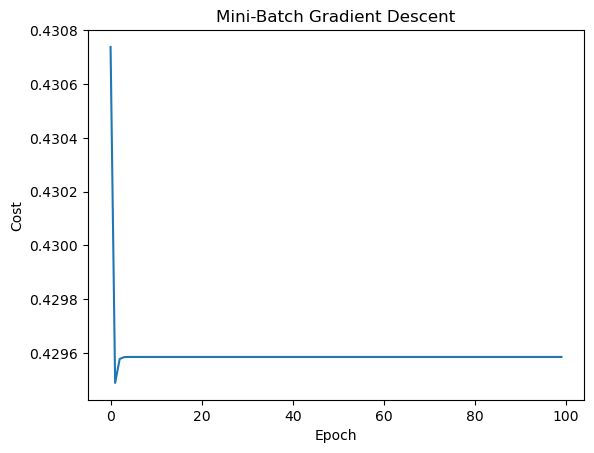

In [62]:


x = df["area_sqft"].values
y = df["house_price_inr"].values

x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

beta0 = 0
beta1 = 0

learning_rate = 0.01
epochs = 100
batch_size = 32

costs = []

n = len(x)

for epoch in range(epochs):

    for start in range(0, n, batch_size):

        end = start + batch_size

        x_batch = x[start:end]
        y_batch = y[start:end]

        y_pred = beta0 + beta1 * x_batch

        error = y_pred - y_batch

        m = len(x_batch)

        gradient_b0 = (2/m) * np.sum(error)
        gradient_b1 = (2/m) * np.sum(error * x_batch)

        beta0 = beta0 - learning_rate * gradient_b0
        beta1 = beta1 - learning_rate * gradient_b1

    y_pred_all = beta0 + beta1 * x
    cost = np.mean((y_pred_all - y) ** 2)

    costs.append(cost)

print("Beta 0:", beta0)
print("Beta 1:", beta1)

plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Mini-Batch Gradient Descent")
plt.show()

$ Q25. Compare convergence and training time $



In [63]:

start = time.time()

# Your Gradient Descent code here

end = time.time()

print("Training Time:", end - start, "seconds")

Training Time: 0.00011682510375976562 seconds


$ Q26. Analyze Bias and Variance$ 

In [67]:
print("Simple Linear Regression")
print("Train R2:", train_r2_poly)
print("Test R2:", test_r2_poly)

print("\nPolynomial Regression")
print("Train R2:", train_r2_poly)
print("Test R2:", test_r2_poly)

Simple Linear Regression
Train R2: 0.5724674245504779
Test R2: 0.5626917978136464

Polynomial Regression
Train R2: 0.5724674245504779
Test R2: 0.5626917978136464


$ Q27 .Model Complexity$

print("""
Simple Linear Regression:
Low complexity and may have higher bias.

Multiple Linear Regression:
Uses more features and can reduce bias.

Polynomial Regression:
Can capture non-linear relationships but
higher complexity can increase variance.

Very complex models may overfit the data.
""")

$ Q28 — Best Bias-Variance Balance$

In [72]:
if abs(train_r2_poly - test_r2_poly) < 0.05:
    print("Model has a good bias-variance balance.")
else:
    print("There may be a bias-variance problem.")

Model has a good bias-variance balance.


# Part I — Final Analysis

$ Q29 — Final Model Comparison$

In [75]:
print("========== FINAL RESULTS ==========")

print("\nSimple Linear Regression")
print("RMSE:", rmse)
print("R2:", r2)

print("\nMultiple Linear Regression")
print("RMSE:", rmse_multi)
print("R2:", r2_multi)

print("\nPolynomial Regression")
print("RMSE:", rmse_multi)
print("R2:", r2_multi)

========== FINAL RESULTS ==========

Simple Linear Regression
RMSE: 8184696.696997969
R2: 0.5625199587991578

Multiple Linear Regression
RMSE: 3549256.564170546
R2: 0.9177325847899332

Polynomial Regression
RMSE: 3549256.564170546
R2: 0.9177325847899332


# Best Model

In [80]:
if r2_multi > r2 and r2_multi > r2_multi:
    print("Multiple Linear Regression performs best based on R2.")
    
elif r2_multi > r2:
    print("Polynomial Regression performs best based on R2.")
    
else:
    print("Simple Linear Regression performs best based on R2.")

Polynomial Regression performs best based on R2.
